# Testing playground

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("data/RTA Dataset.csv")

In [3]:
print(df.shape)
print(df.head())

(12316, 32)
       Time Day_of_week Age_band_of_driver Sex_of_driver   Educational_level  \
0  17:02:00      Monday              18-30          Male   Above high school   
1  17:02:00      Monday              31-50          Male  Junior high school   
2  17:02:00      Monday              18-30          Male  Junior high school   
3   1:06:00      Sunday              18-30          Male  Junior high school   
4   1:06:00      Sunday              18-30          Male  Junior high school   

  Vehicle_driver_relation Driving_experience      Type_of_vehicle  \
0                Employee              1-2yr           Automobile   
1                Employee         Above 10yr  Public (> 45 seats)   
2                Employee              1-2yr      Lorry (41?100Q)   
3                Employee             5-10yr  Public (> 45 seats)   
4                Employee              2-5yr                  NaN   

  Owner_of_vehicle Service_year_of_vehicle  ... Vehicle_movement  \
0            Owner      

In [4]:
for col in df.columns:
    print(f"\n\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("NaN count:", df[col].isna().sum())



Column: Time
Unique values: <StringArray>
['17:02:00',  '1:06:00', '14:15:00', '17:30:00', '17:20:00', '14:40:00',
 '17:45:00', '22:45:00',  '8:20:00', '15:10:00',
 ...
 '23:55:00', '15:58:00', '10:26:00',  '5:53:00',  '8:34:00', '22:11:00',
  '7:02:00',  '7:24:00', '19:18:00',  '2:47:00']
Length: 1074, dtype: str
NaN count: 0


Column: Day_of_week
Unique values: <StringArray>
['Monday', 'Sunday', 'Friday', 'Wednesday', 'Saturday', 'Thursday', 'Tuesday']
Length: 7, dtype: str
NaN count: 0


Column: Age_band_of_driver
Unique values: <StringArray>
['18-30', '31-50', 'Under 18', 'Over 51', 'Unknown']
Length: 5, dtype: str
NaN count: 0


Column: Sex_of_driver
Unique values: <StringArray>
['Male', 'Female', 'Unknown']
Length: 3, dtype: str
NaN count: 0


Column: Educational_level
Unique values: <StringArray>
[ 'Above high school', 'Junior high school',                  nan,
  'Elementary school',        'High school',            'Unknown',
         'Illiterate',  'Writing & reading']
Leng

In [5]:
(df['Accident_severity']
 .value_counts(normalize=True)
 .mul(100)
 .round(2)
 .astype(str) + '%')

Accident_severity
Slight Injury     84.56%
Serious Injury    14.15%
Fatal injury       1.28%
Name: proportion, dtype: str

# Time features

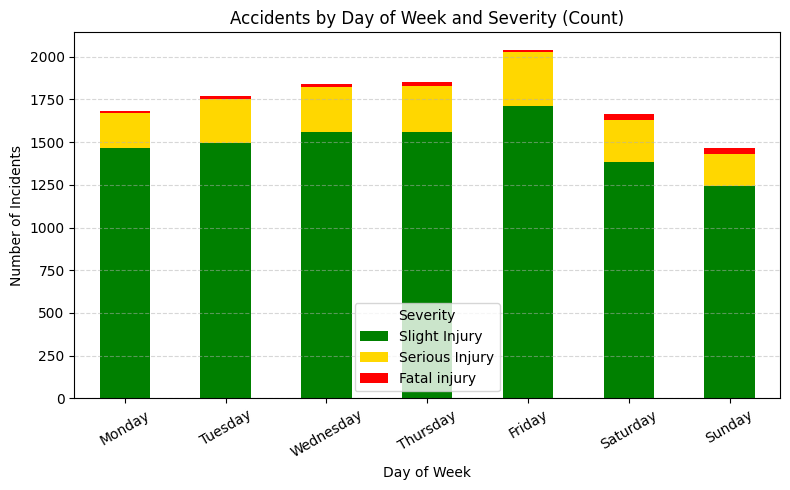

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# thứ tự ngày chuẩn
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# pivot theo severity
pivot = pd.crosstab(
    df['Day_of_week'],
    df['Accident_severity']
)

# đảm bảo thứ tự + đủ class
cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(day_order)
pivot = pivot.reindex(columns=cols, fill_value=0)

# màu
color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}

# plot
pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=[color_map[c] for c in pivot.columns]
)

plt.title('Accidents by Day of Week and Severity (Count)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=30)
plt.legend(title='Severity')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
df['Time_cat'] = (
    pd.to_datetime(df['Time'], format='%H:%M:%S')
    .dt.round('30min')
    .dt.strftime('%H:%M')
)

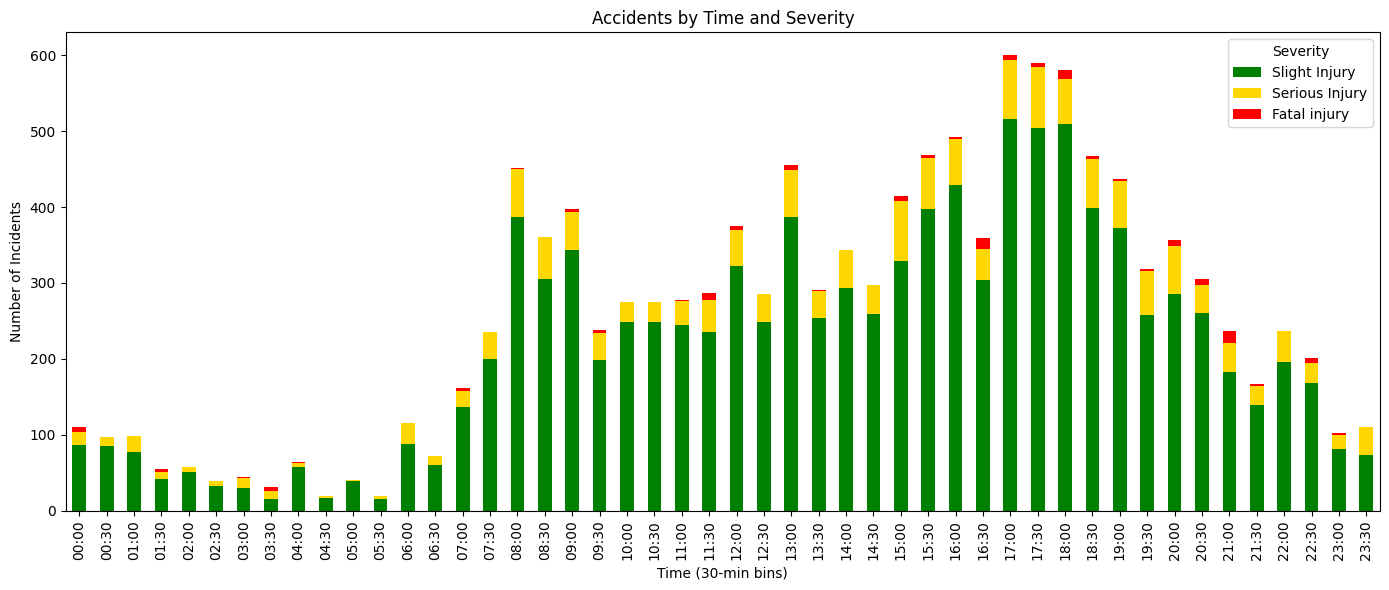

In [8]:
import matplotlib.pyplot as plt

pivot = pd.crosstab(
    df['Time_cat'],
    df['Accident_severity']
)

pivot = pivot.sort_index()

pivot = pivot[['Slight Injury', 'Serious Injury', 'Fatal injury']]

colors = ['green', 'gold', 'red']

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6),
    color=colors
)

plt.xticks(rotation=90)
plt.xlabel('Time (30-min bins)')
plt.ylabel('Number of Incidents')
plt.title('Accidents by Time and Severity')
plt.legend(title='Severity')
plt.tight_layout()
plt.show()

# Driver features

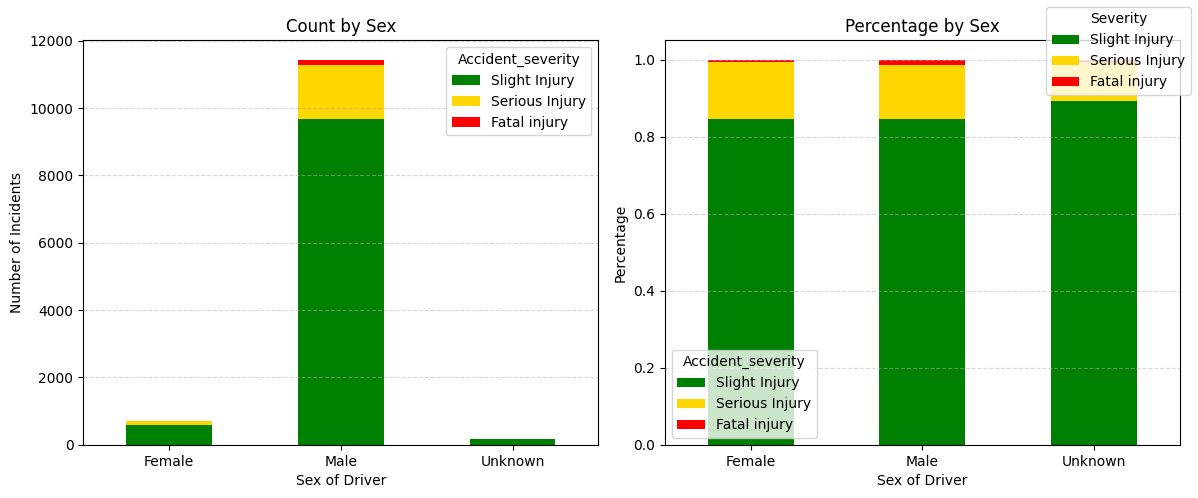

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# --- pivot ---
pivot = pd.crosstab(
    df['Sex_of_driver'],
    df['Accident_severity']
)

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}

# --- figure ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ===== Plot 1: Count =====
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)

axes[0].set_title('Count by Sex')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_xlabel('Sex of Driver')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ===== Plot 2: Percentage =====
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)

axes[1].set_title('Percentage by Sex')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Sex of Driver')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# legend chung
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Severity', loc='upper right')

plt.tight_layout()
plt.show()

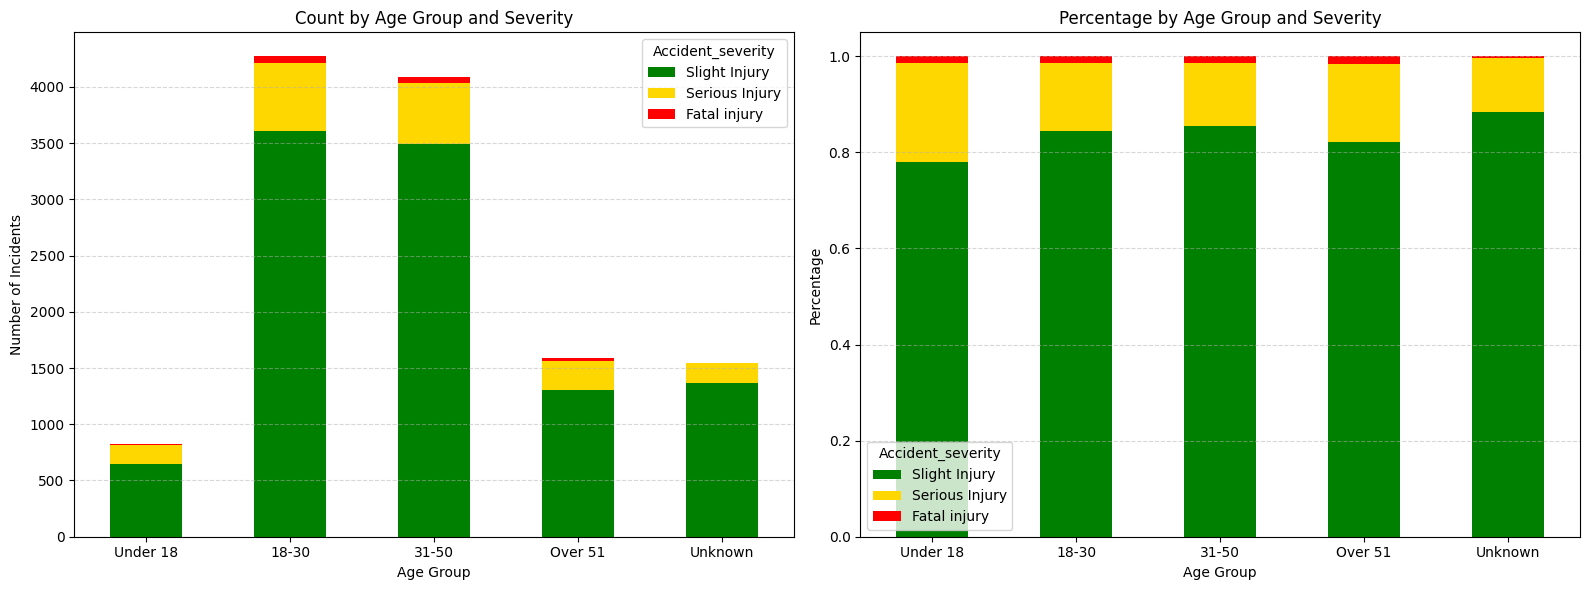

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# --- pivot ---
pivot = pd.crosstab(
    df['Age_band_of_driver'],
    df['Accident_severity']
)

age_order = ['Under 18', '18-30', '31-50', 'Over 51', 'Unknown']
pivot = pivot.reindex(age_order)

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

# --- color ---
color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}

# --- figure ---
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ===== Plot 1: Count =====
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)

axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_title('Count by Age Group and Severity')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ===== Plot 2: Percentage =====
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)

axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Percentage by Age Group and Severity')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [11]:
df['Driving_experience'] = (
    df['Driving_experience']
    .str.strip()
    .str.title()
    .replace({'Unknown': 'Unknown'})
    .fillna('Missing')
)


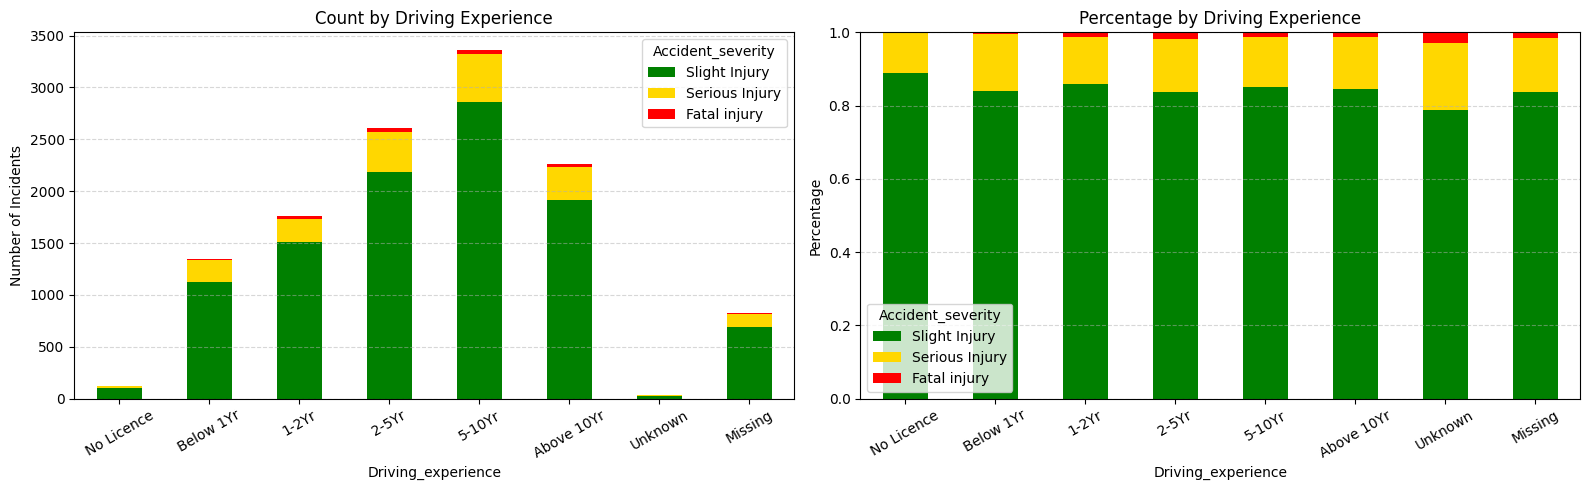

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}
cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']

pivot = pd.crosstab(df['Driving_experience'], df['Accident_severity'])
pivot = pivot.reindex(columns=cols, fill_value=0)

exp_order = [
    'No Licence', 'Below 1Yr', '1-2Yr', '2-5Yr',
    '5-10Yr', 'Above 10Yr', 'Unknown', 'Missing'
]
pivot = pivot.reindex(exp_order)

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# --- Plot 1: Count ---
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)
axes[0].set_title('Count by Driving Experience')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Percentage ---
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)
axes[1].set_title('Percentage by Driving Experience')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
df['Educational_level'] = (
    df['Educational_level']
    .str.strip()
    .str.title()
    .replace({
        'Writing & Reading': 'Literate',
        'Above High School': 'Post-Secondary'
    })
    .fillna('Missing')
)

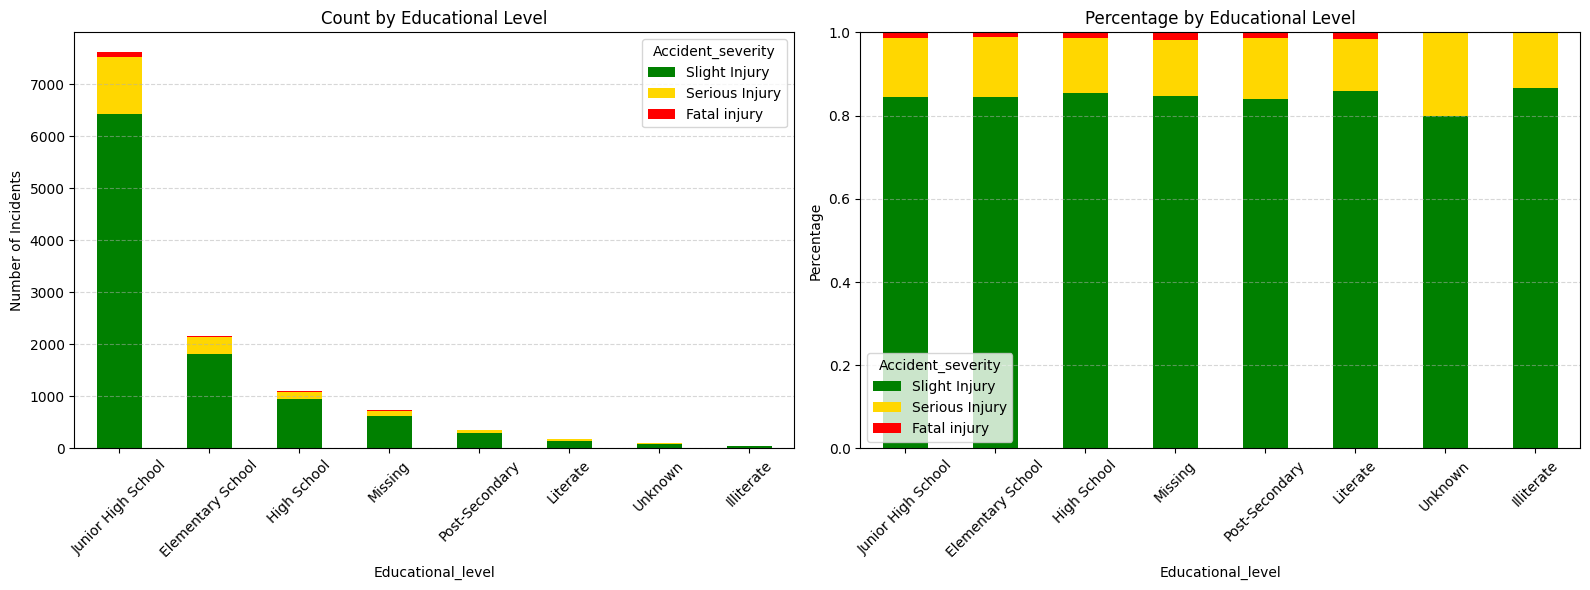

In [14]:
pivot = pd.crosstab(
    df['Educational_level'],
    df['Accident_severity']
)

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

# sort theo số lượng cho dễ nhìn
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# --- Color ---
color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ===== Count =====
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)
axes[0].set_title('Count by Educational Level')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ===== Percentage =====
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)
axes[1].set_title('Percentage by Educational Level')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [15]:
df['Vehicle_driver_relation'] = (
    df['Vehicle_driver_relation']
    .str.strip()
    .str.title()
    .replace({
        'Other': 'Unknown',
        'Missing': 'Unknown'
    })
    .fillna('Unknown')
)

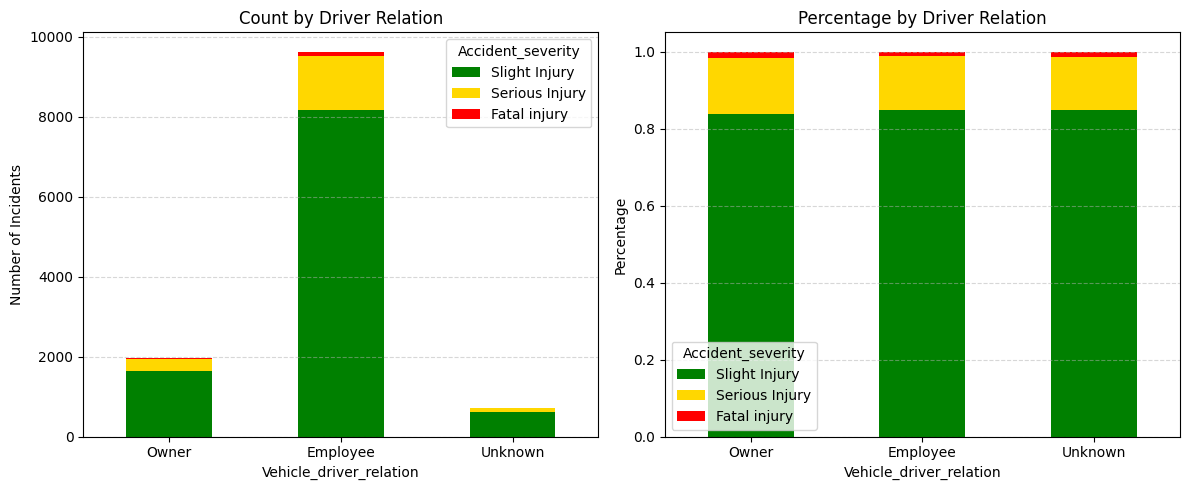

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Clean + group (cách 2) ---
df['Vehicle_driver_relation'] = (
    df['Vehicle_driver_relation']
    .str.strip()
    .str.title()
    .replace({
        'Other': 'Unknown'
    })
    .fillna('Unknown')
)

# --- Pivot ---
pivot = pd.crosstab(
    df['Vehicle_driver_relation'],
    df['Accident_severity']
)

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

# order cho đẹp
order = ['Owner', 'Employee', 'Unknown']
pivot = pivot.reindex(order)

# --- Color ---
color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ===== Count =====
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)
axes[0].set_title('Count by Driver Relation')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ===== Percentage =====
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)
axes[1].set_title('Percentage by Driver Relation')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Vehicle features

In [17]:
# chuẩn hóa luôn trên cột gốc
df['Owner_of_vehicle'] = (
    df['Owner_of_vehicle']
    .astype(str)
    .str.strip()
    .str.title()
)

# sửa 'nan' string thành NaN thật
df['Owner_of_vehicle'] = df['Owner_of_vehicle'].replace('Missing', np.nan)

# fill luôn
df['Owner_of_vehicle'] = df['Owner_of_vehicle'].fillna('Unknown')

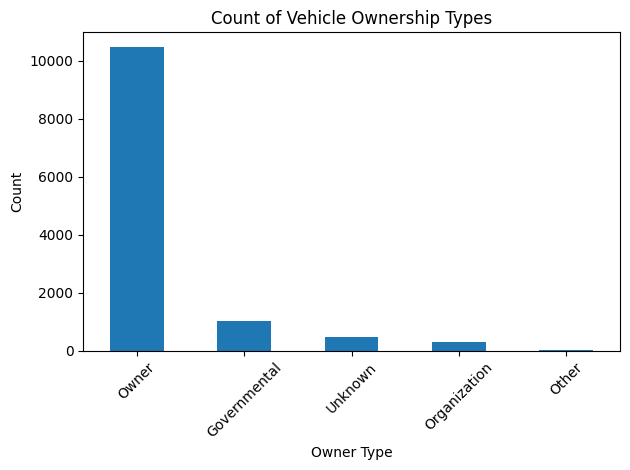

In [18]:
import matplotlib.pyplot as plt

df['Owner_of_vehicle'].value_counts().plot.bar()

plt.title('Count of Vehicle Ownership Types')
plt.xlabel('Owner Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
df['Type_of_vehicle'] = (
    df['Type_of_vehicle']
    .str.strip()
    .str.title()
    .fillna('Missing')
)

vehicle_map = {
    'Automobile': 'Car',
    'Taxi': 'Car',
    'Stationwagen': 'Car',

    'Motorcycle': 'Motorcycle',
    'Bicycle': 'Motorcycle',
    'Bajaj': 'Motorcycle',

    'Lorry (11?40Q)': 'Truck',
    'Lorry (41?100Q)': 'Truck',
    'Long Lorry': 'Truck',

    'Public (> 45 Seats)': 'Bus',
    'Public (13?45 Seats)': 'Bus',
    'Public (12 Seats)': 'Bus',

    'Pick Up Upto 10Q': 'Pickup',

    'Other': 'Other',
    'Turbo': 'Other',
    'Special Vehicle': 'Other',

    'Ridden Horse': 'Other',
    'Missing': 'Missing'
}

df['Type_of_vehicle'] = df['Type_of_vehicle'].replace(vehicle_map)

df['Type_of_vehicle'] = df['Type_of_vehicle'].astype('category')

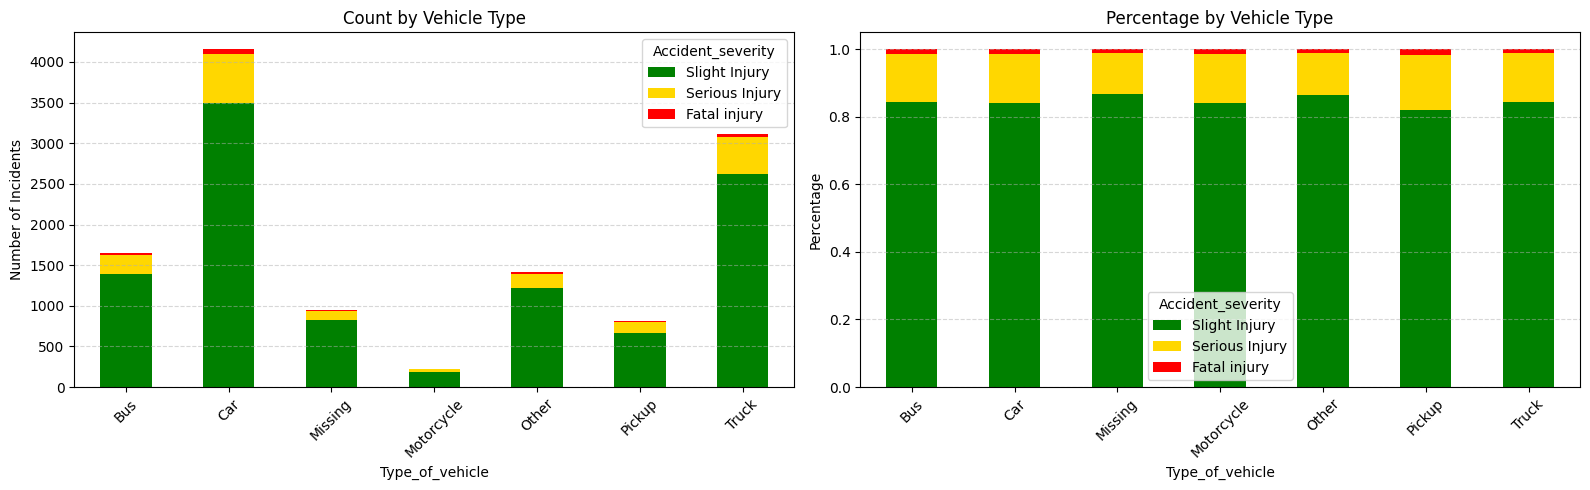

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}
cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']

pivot = pd.crosstab(df['Type_of_vehicle'], df['Accident_severity'])
pivot = pivot.reindex(columns=cols, fill_value=0)
pivot = pivot.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# --- Plot 1: Count ---
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)
axes[0].set_title('Count by Vehicle Type')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Percentage ---
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)
axes[1].set_title('Percentage by Vehicle Type')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
# --- Clean ---
df['Service_year_of_vehicle'] = (
    df['Service_year_of_vehicle']
    .str.strip()
    .str.title()
    .replace({
        '5-10Yrs': '5-10Yr',
        '2-5Yrs': '2-5Yr'
    })
    .fillna('Unknown')
)

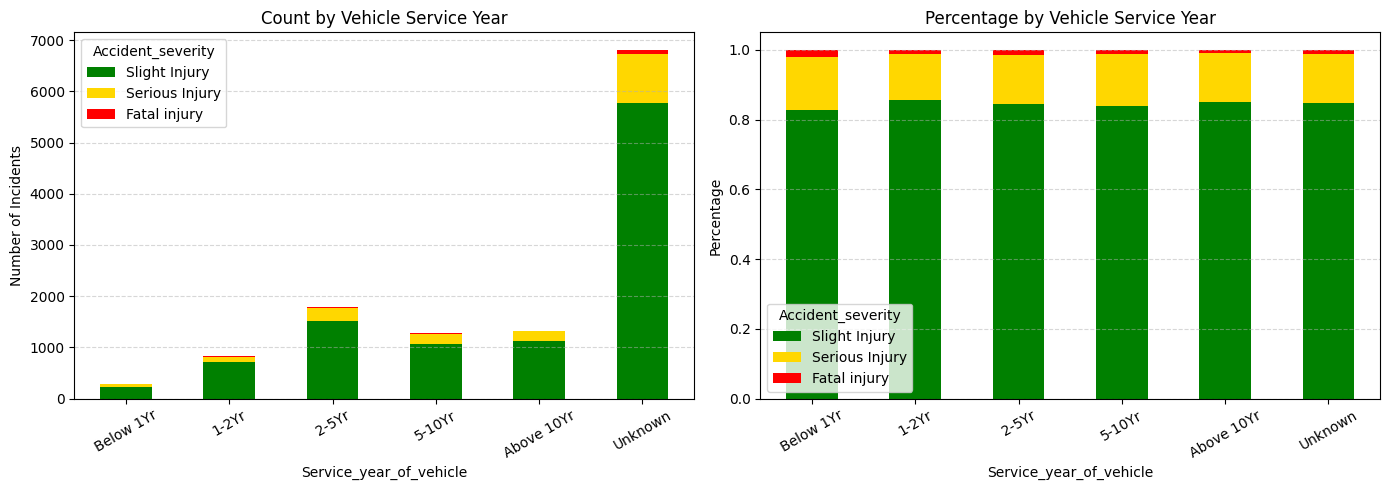

(Accident_severity        Slight Injury  Serious Injury  Fatal injury
 Service_year_of_vehicle                                             
 Below 1Yr                          233              43             6
 1-2Yr                              707             111             9
 2-5Yr                             1511             253            28
 5-10Yr                            1073             191            16
 Above 10Yr                        1126             186            12
 Unknown                           5765             959            87,
 Accident_severity        Slight Injury  Serious Injury  Fatal injury
 Service_year_of_vehicle                                             
 Below 1Yr                     0.826241        0.152482      0.021277
 1-2Yr                         0.854897        0.134220      0.010883
 2-5Yr                         0.843192        0.141183      0.015625
 5-10Yr                        0.838281        0.149219      0.012500
 Above 10Yr        

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Pivot ---
pivot = pd.crosstab(
    df['Service_year_of_vehicle'],
    df['Accident_severity']
)

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

# order theo tuổi xe (quan trọng)
order = ['Below 1Yr', '1-2Yr', '2-5Yr', '5-10Yr', 'Above 10Yr', 'Unknown']
pivot = pivot.reindex(order)

# --- Color ---
color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ===== Count =====
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)
axes[0].set_title('Count by Vehicle Service Year')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ===== Percentage =====
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)
axes[1].set_title('Percentage by Vehicle Service Year')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- In pivot để bạn xem trực tiếp ---
pivot, pivot_pct

# Area features

In [23]:
df['Area_accident_occured'] = (
    df['Area_accident_occured']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
    .fillna('Missing')
)

df['Area_accident_occured'] = df['Area_accident_occured'].replace({
    'Rural Village Areasoffice Areas': 'Mixed Area'
})

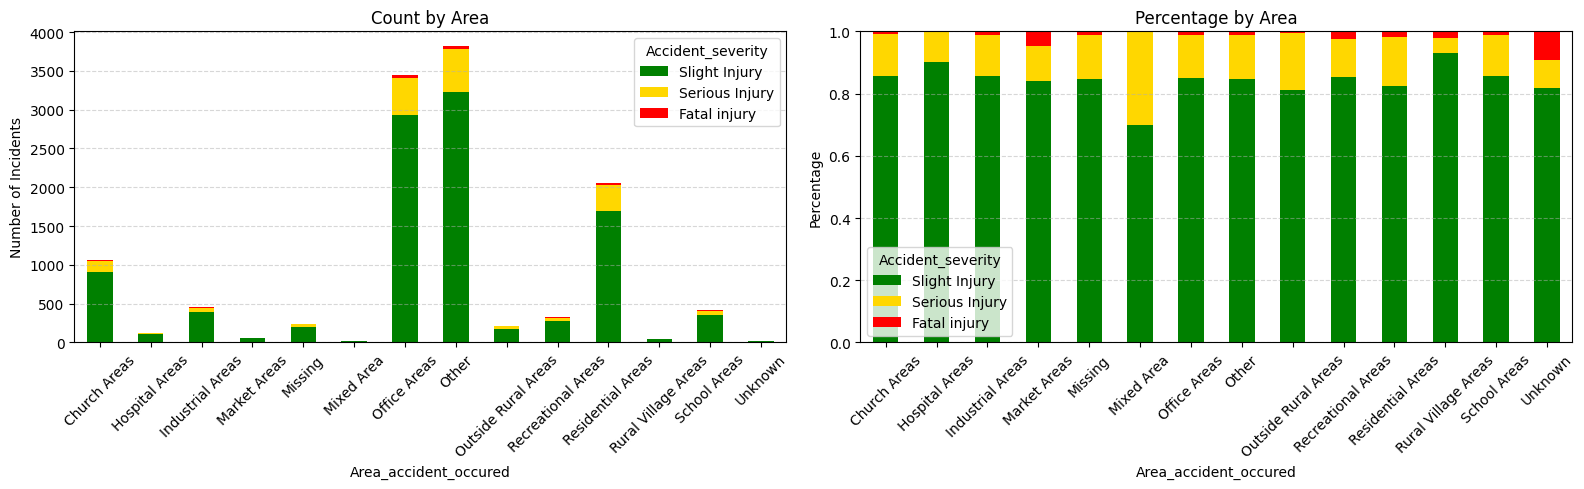

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}
cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']

pivot = pd.crosstab(df['Area_accident_occured'], df['Accident_severity'])
pivot = pivot.reindex(columns=cols, fill_value=0)
pivot = pivot.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# --- Plot 1: Count ---
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)
axes[0].set_title('Count by Area')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Percentage ---
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)
axes[1].set_title('Percentage by Area')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [25]:
df['Lanes_or_Medians'] = (
    df['Lanes_or_Medians']
    .str.strip()
    .str.title()
    .replace({
        'Other': 'Other',
        'Unknown': 'Unknown'
    })
    .fillna('Unknown')
)

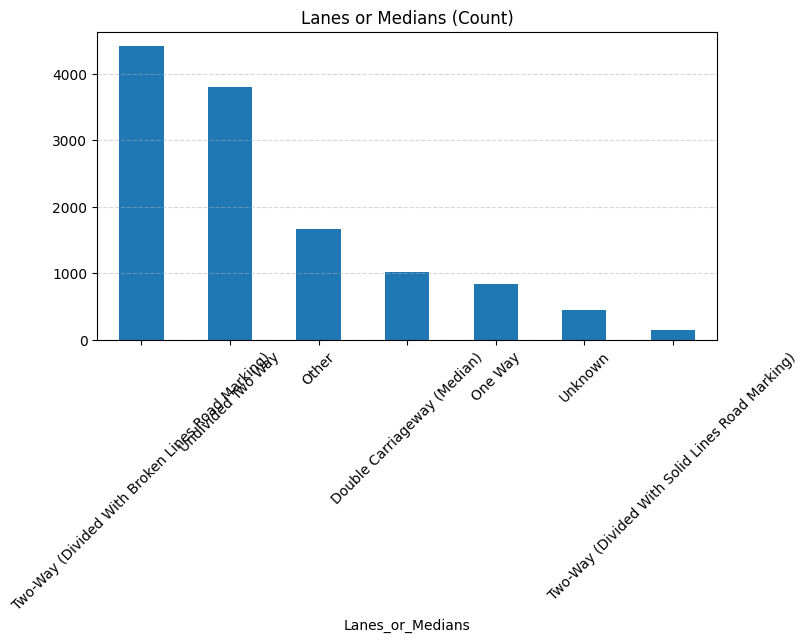

In [26]:
df['Lanes_or_Medians'].value_counts().plot(
    kind='bar',
    figsize=(8,4)
)
plt.title('Lanes or Medians (Count)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [27]:
df['Road_allignment'] = (
    df['Road_allignment']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
    .fillna('Unknown')
)

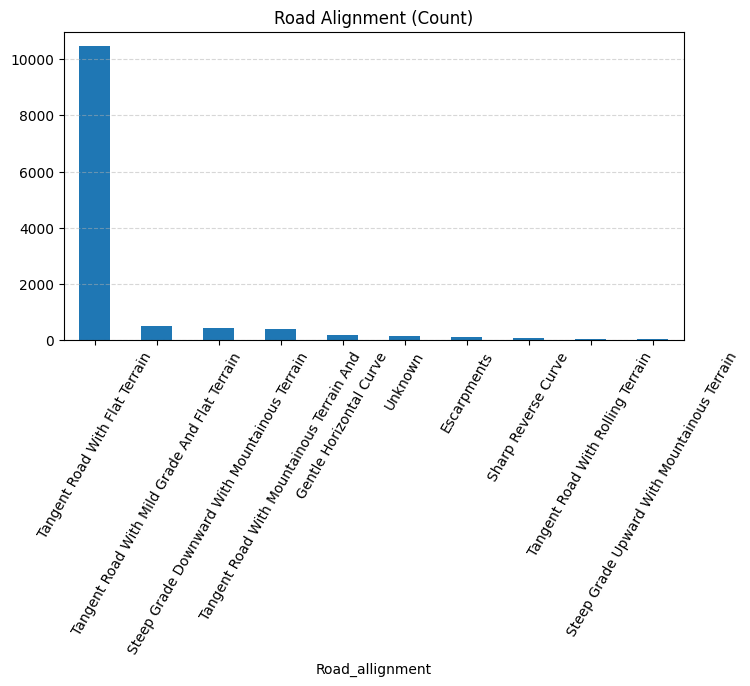

In [28]:
df['Road_allignment'].value_counts().plot(
    kind='bar',
    figsize=(8,4)
)
plt.title('Road Alignment (Count)')
plt.xticks(rotation=60)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [29]:
df['Types_of_Junction'] = (
    df['Types_of_Junction']
    .str.strip()
    .str.title()
    .fillna('Unknown')
)

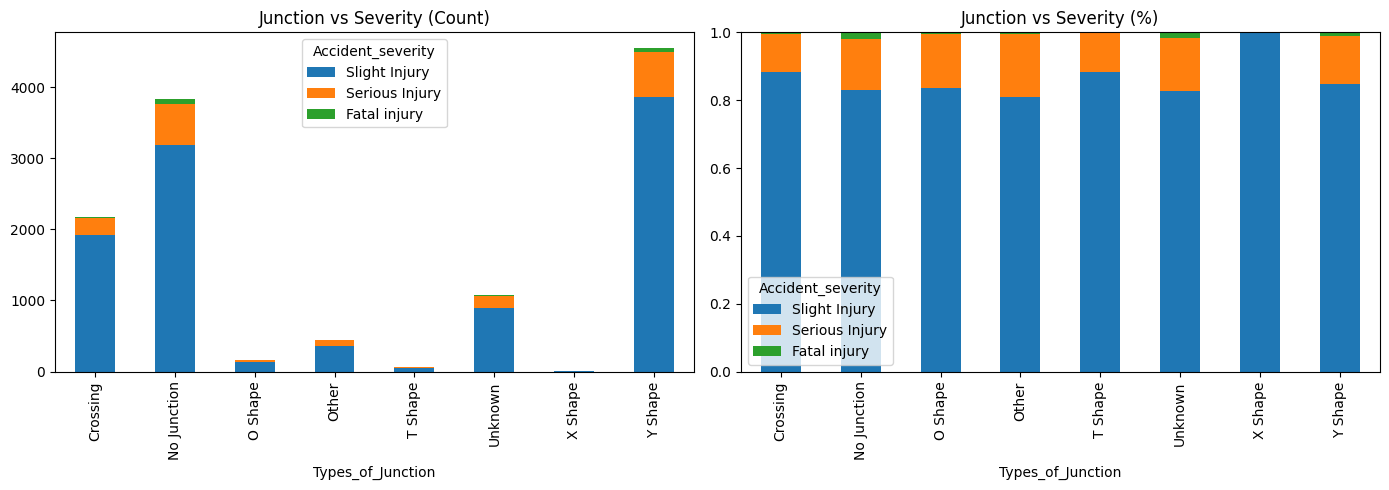

In [30]:
pivot = pd.crosstab(df['Types_of_Junction'], df['Accident_severity'])

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Count
pivot.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Junction vs Severity (Count)')

# %
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Junction vs Severity (%)')

plt.tight_layout()
plt.show()

In [31]:
df['Road_surface_type'] = (
    df['Road_surface_type']
    .str.strip()
    .str.title()
    .fillna('Unknown')
)

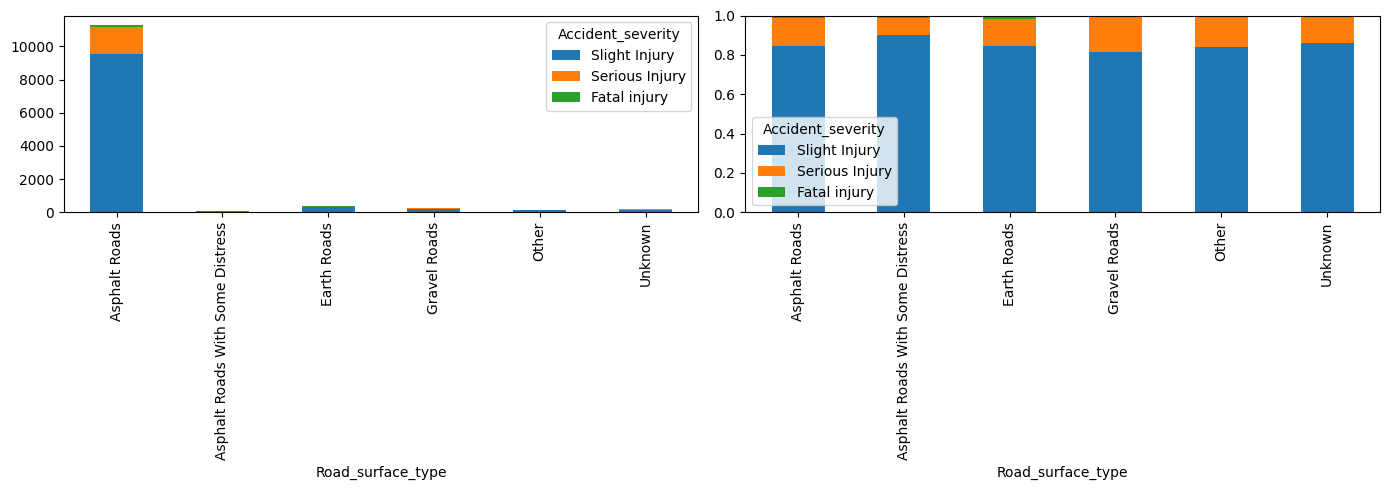

In [32]:
pivot = pd.crosstab(df['Road_surface_type'], df['Accident_severity'])
pivot = pivot.reindex(columns=cols, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

pivot.plot(kind='bar', stacked=True, ax=axes[0])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1])

plt.tight_layout()
plt.show()

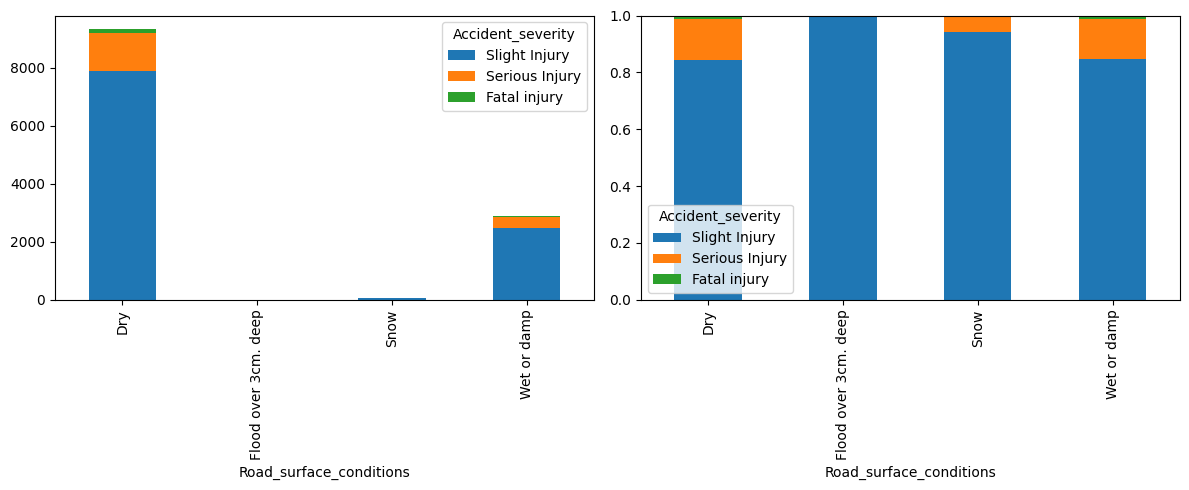

In [33]:
pivot = pd.crosstab(df['Road_surface_conditions'], df['Accident_severity'])
pivot = pivot.reindex(columns=cols, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

pivot.plot(kind='bar', stacked=True, ax=axes[0])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1])

plt.tight_layout()
plt.show()

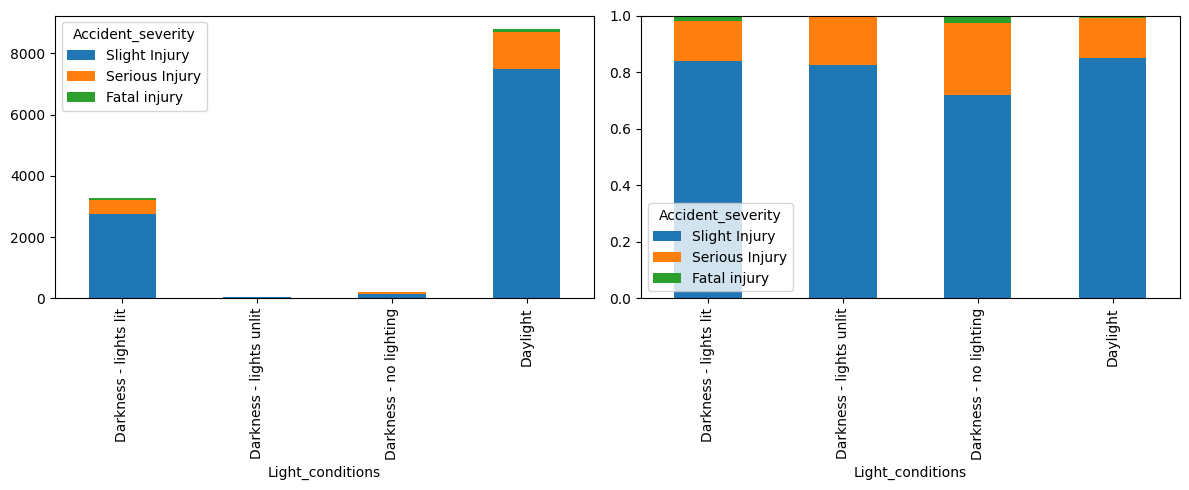

In [34]:
pivot = pd.crosstab(df['Light_conditions'], df['Accident_severity'])
pivot = pivot.reindex(columns=cols, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

pivot.plot(kind='bar', stacked=True, ax=axes[0])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [35]:
df['Weather_conditions'] = df['Weather_conditions'].str.title()

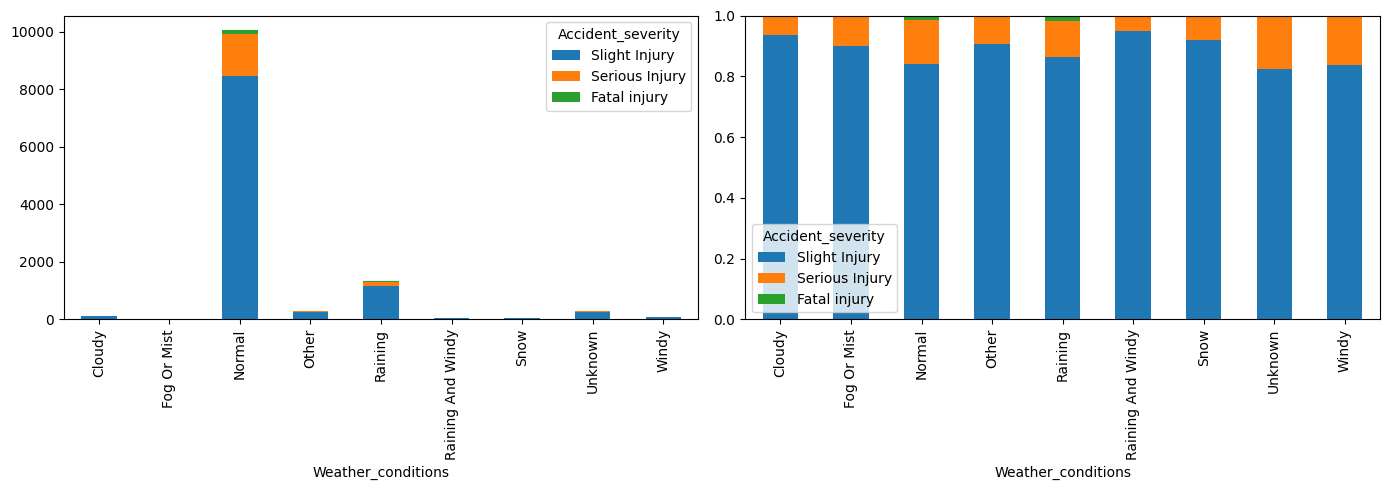

In [36]:
pivot = pd.crosstab(df['Weather_conditions'], df['Accident_severity'])
pivot = pivot.reindex(columns=cols, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

pivot.plot(kind='bar', stacked=True, ax=axes[0])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [37]:
df['Type_of_collision'] = (
    df['Type_of_collision']
    .str.strip()
    .str.title()
    .fillna('Unknown')
)

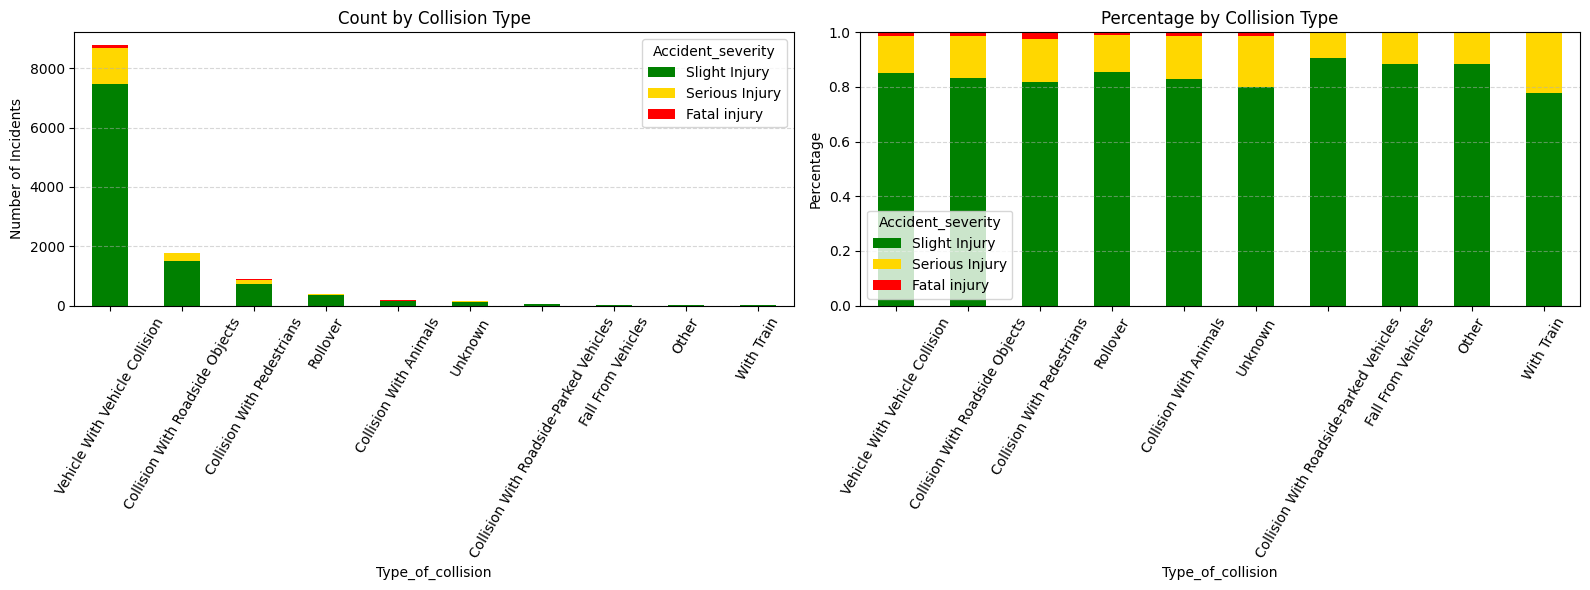

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Clean ---
df['Type_of_collision'] = (
    df['Type_of_collision']
    .str.strip()
    .str.title()
    .fillna('Unknown')
)

# --- Pivot ---
pivot = pd.crosstab(
    df['Type_of_collision'],
    df['Accident_severity']
)

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

# sort theo số lượng cho dễ nhìn
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# --- Color ---
color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ===== Count =====
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[color_map[c] for c in pivot.columns]
)
axes[0].set_title('Count by Collision Type')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=60)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ===== Percentage =====
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in pivot.columns]
)
axes[1].set_title('Percentage by Collision Type')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=60)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [41]:
df['Has_pedestrian'] = (
    df['Pedestrian_movement'] != 'Not a Pedestrian'
).astype(int)

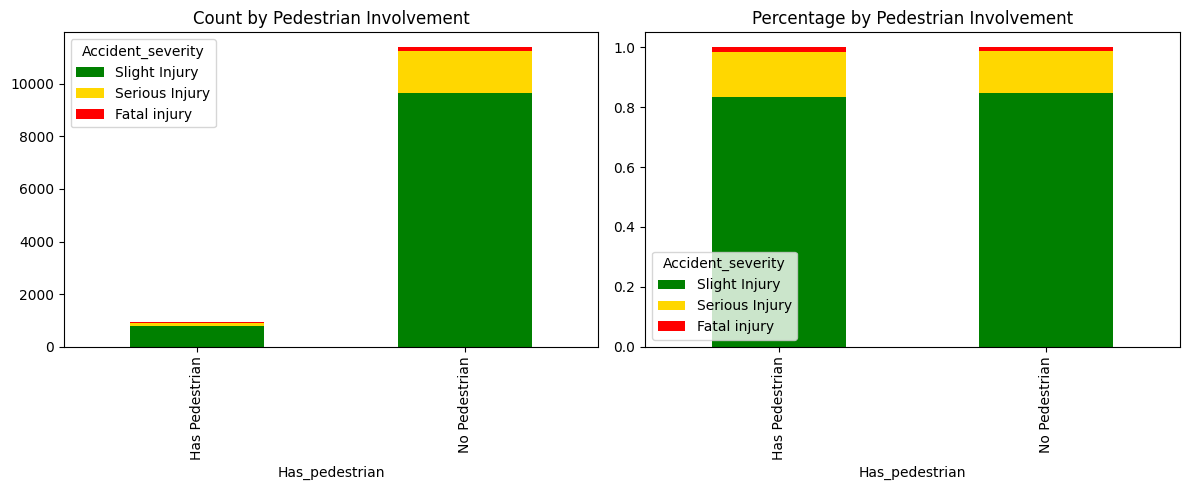

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Feature ---
df['Has_pedestrian'] = (
    df['Pedestrian_movement'] != 'Not a Pedestrian'
).astype(int)

df['Has_pedestrian'] = df['Has_pedestrian'].map({
    0: 'No Pedestrian',
    1: 'Has Pedestrian'
})

# --- Pivot ---
pivot = pd.crosstab(
    df['Has_pedestrian'],
    df['Accident_severity']
)

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

# --- Color ---
color_map = {
    'Slight Injury': 'green',
    'Serious Injury': 'gold',
    'Fatal injury': 'red'
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Count
pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=[color_map[c] for c in pivot.columns])
axes[0].set_title('Count by Pedestrian Involvement')

# %
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=[color_map[c] for c in pivot.columns])
axes[1].set_title('Percentage by Pedestrian Involvement')

plt.tight_layout()
plt.show()

In [43]:
cause_map = {
    # Speed
    'Overspeed': 'Speed',
    'Driving At High Speed': 'Speed',

    # Careless
    'Driving Carelessly': 'Careless',
    'No Distancing': 'Careless',

    # Lane violation
    'Changing Lane To The Left': 'Lane',
    'Changing Lane To The Right': 'Lane',

    # Priority
    'No Priority To Vehicle': 'Priority',
    'No Priority To Pedestrian': 'Priority',

    # Parking / movement
    'Improper Parking': 'Parking',
    'Moving Backward': 'Movement',
    'Getting Off The Vehicle Improperly': 'Movement',

    # Overtake
    'Overtaking': 'Overtake',

    # Substance (QUAN TRỌNG)
    'Drunk Driving': 'Substance',
    'Driving Under The Influence Of Drugs': 'Substance',

    # Others
    'Overloading': 'Other',
    'Turnover': 'Other',
    'Overturning': 'Other',
    'Driving To The Left': 'Other',
    'Other': 'Other',
    'Unknown': 'Unknown'
}

df['Cause_of_accident'] = (
    df['Cause_of_accident']
    .str.title()
    .replace(cause_map)
)

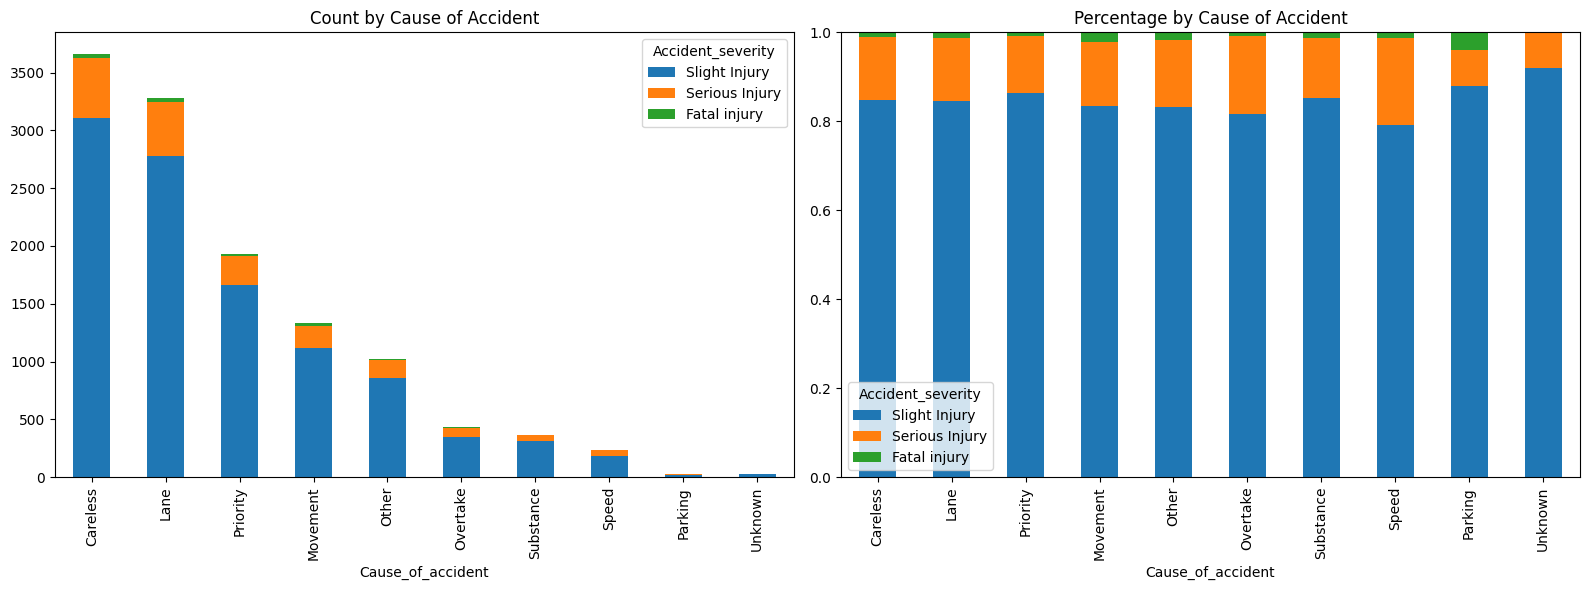

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Clean + Map ---
cause_map = {
    'Overspeed': 'Speed',
    'Driving At High Speed': 'Speed',

    'Driving Carelessly': 'Careless',
    'No Distancing': 'Careless',

    'Changing Lane To The Left': 'Lane',
    'Changing Lane To The Right': 'Lane',

    'No Priority To Vehicle': 'Priority',
    'No Priority To Pedestrian': 'Priority',

    'Improper Parking': 'Parking',
    'Moving Backward': 'Movement',
    'Getting Off The Vehicle Improperly': 'Movement',

    'Overtaking': 'Overtake',

    'Drunk Driving': 'Substance',
    'Driving Under The Influence Of Drugs': 'Substance',

    'Overloading': 'Other',
    'Turnover': 'Other',
    'Overturning': 'Other',
    'Driving To The Left': 'Other',
    'Other': 'Other',
    'Unknown': 'Unknown'
}

df['Cause_of_accident'] = (
    df['Cause_of_accident']
    .str.title()
    .replace(cause_map)
)

# --- Pivot ---
pivot = pd.crosstab(
    df['Cause_of_accident'],
    df['Accident_severity']
)

cols = ['Slight Injury', 'Serious Injury', 'Fatal injury']
pivot = pivot.reindex(columns=cols, fill_value=0)

# sort theo count
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Count
pivot.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Count by Cause of Accident')

# %
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Percentage by Cause of Accident')

plt.tight_layout()
plt.show()

In [ ]:
# Noise
df.drop(columns=['Defect_of_vehicle', 'Age_band_of_casualty', 'Sex_of_casualty', 'Casualty_class', 'Work_of_casuality', 'Fitness_of_casuality'], inplace=True)

# Data leakage
df.drop(columns=['Casualty_severity'], inplace=True)



In [39]:
for col in df.columns:
    print(f"\n\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("NaN count:", df[col].isna().sum())



Column: Time
Unique values: <StringArray>
['17:02:00',  '1:06:00', '14:15:00', '17:30:00', '17:20:00', '14:40:00',
 '17:45:00', '22:45:00',  '8:20:00', '15:10:00',
 ...
 '23:55:00', '15:58:00', '10:26:00',  '5:53:00',  '8:34:00', '22:11:00',
  '7:02:00',  '7:24:00', '19:18:00',  '2:47:00']
Length: 1074, dtype: str
NaN count: 0


Column: Day_of_week
Unique values: <StringArray>
['Monday', 'Sunday', 'Friday', 'Wednesday', 'Saturday', 'Thursday', 'Tuesday']
Length: 7, dtype: str
NaN count: 0


Column: Age_band_of_driver
Unique values: <StringArray>
['18-30', '31-50', 'Under 18', 'Over 51', 'Unknown']
Length: 5, dtype: str
NaN count: 0


Column: Sex_of_driver
Unique values: <StringArray>
['Male', 'Female', 'Unknown']
Length: 3, dtype: str
NaN count: 0


Column: Educational_level
Unique values: <StringArray>
[    'Post-Secondary', 'Junior High School',            'Missing',
  'Elementary School',        'High School',            'Unknown',
         'Illiterate',           'Literate']
Leng